# Advanced Automation 2025/26 - Assignment 1

To be delivered until 2025-12-05 23:59:59.

**Submission Notes**:
- Create a folder in your group's GitHub repository to solve this assignment. Copy this notebook into that folder.
- You should commit regularly to your repository the answers to the questions in this notebook. If you do not, your grade will be penalized by 1/20 points.
- After running the entire notebook (including graphs and outputs), save the notebook as a .pdf file, by going to File - Print - Destination: Save as PDF.
- Create a .zip file containing both the .ipynb file (the notebook itself) and the .pdf and submit it in Fénix.

# Problem description

The dataset for this assignment contains information on students from two Portuguese secondary schools enrolled in a mathematics course.
Each row corresponds to one student and includes demographic and family background variables (e.g., basic personal and household characteristics), school-related variables (e.g., school context, study habits, past failures), behavioral and lifestyle indicators (e.g., free time, going out, alcohol use), and the grades for the three school periods, on a 0–20 scale.

The goal is to predict the performance of the students in the final period.
First, the problem will be approached as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course.
Then, the problem will be approached as a regression task, predicting the actual final grade (G3).

A detailed description of all variables (family context, behavioral, school performance, etc.) is provided in the file `variable_description.txt`.

In [6]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('white')

# Part 1 - Data exploration **(4.00)**

##### **1.1.** Load the dataset from the CSV file `mathematics_grades.csv`. **(0.25)**

In [7]:
df = pd.read_csv("mathematics_grades.csv")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,failed
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,True
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,True
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,False
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,False
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,False


##### **1.2.** Identify the feature types of each variable in the dataset. **(1.50)**

In [8]:
numerical = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

ordinal = []
for col in numerical:
    unique_vals = df[col].dropna().unique()
    if len(unique_vals) <= 7 and df[col].dtype == "int64":
        ordinal.append(col)

numerical = [c for c in numerical if c not in ordinal]

print("Numerical columns:", numerical)
print("Categorical columns:", categorical)
print("Ordinal columns:", ordinal)


Numerical columns: ['age', 'absences', 'G1', 'G2', 'G3']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'failed']
Ordinal columns: ['Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


##### **1.3** Check if the dataset has missing values. If so, discard any row that has a missing value. **(0.25)**

In [9]:
total_missing = df.isnull().sum().sum()

if total_missing > 0:
    df_clean = df.dropna()
    print("\nRows before cleaning:", len(df))
    print("Rows after cleaning :", len(df_clean))
else:
    print("\nNo missing values were found.")


No missing values were found.


##### **1.4.** Make a pairplot of the numerical variables, colored by the `failed` variable. **(0.50)**

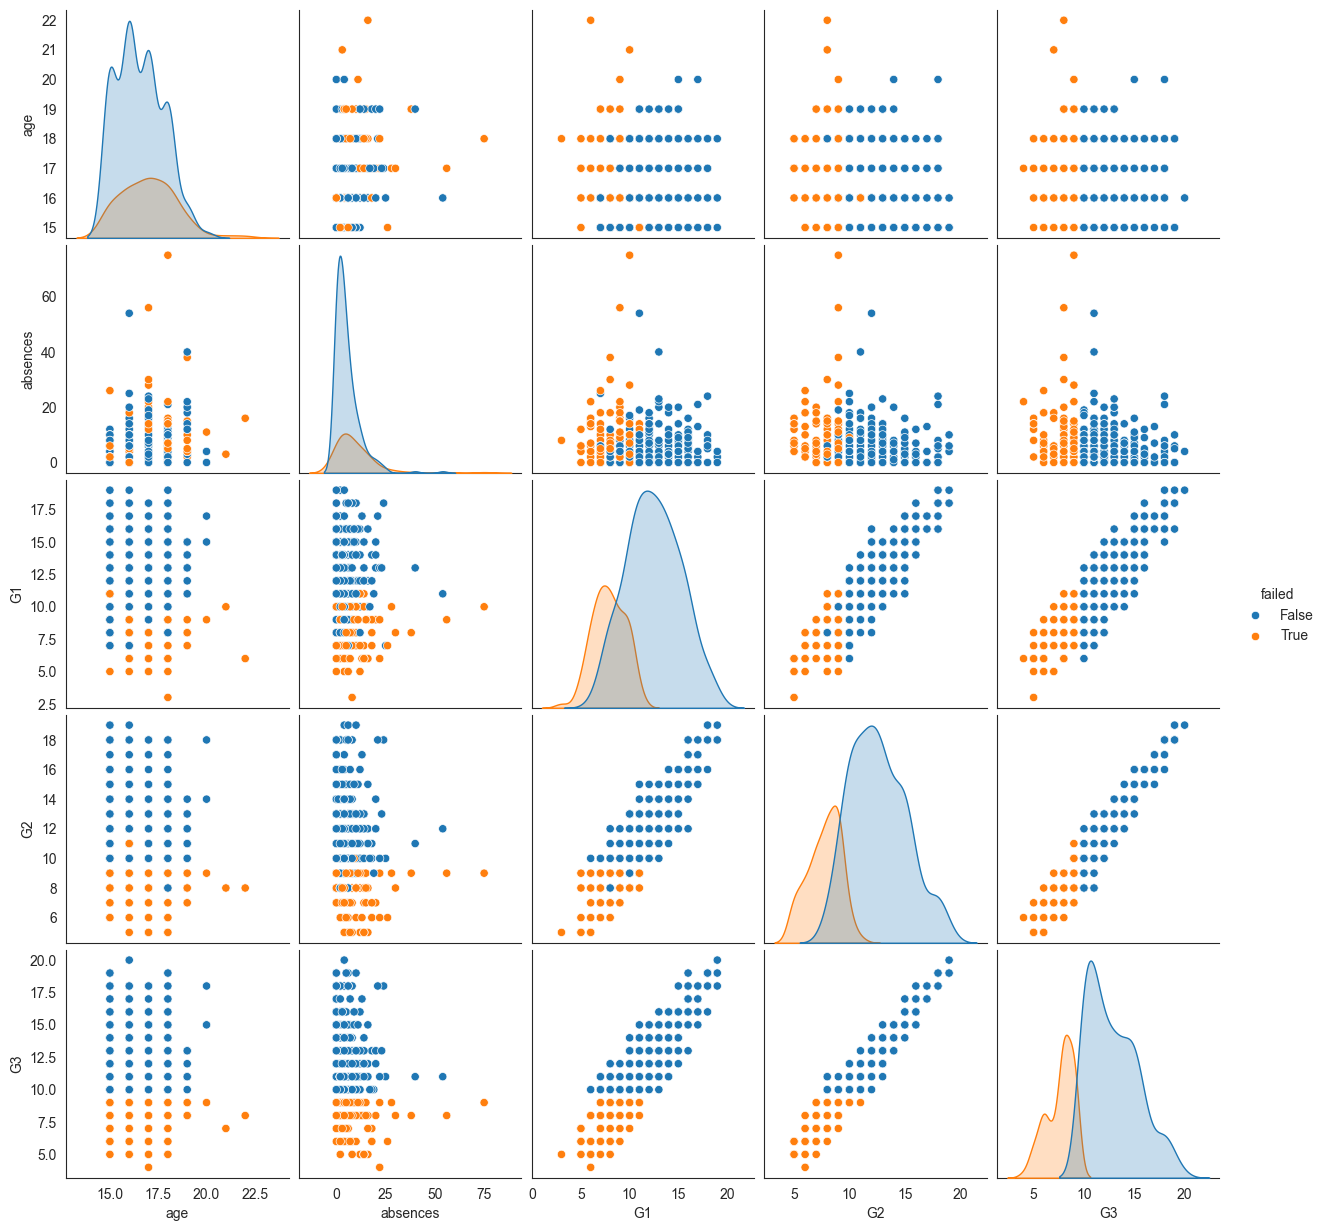

In [10]:
sns.pairplot(df, vars=numerical, hue="failed")

##### **1.5.** Make bar plots for each categorical variable, showing the counts for each category, colored by the `failed` variable. **(0.50)**

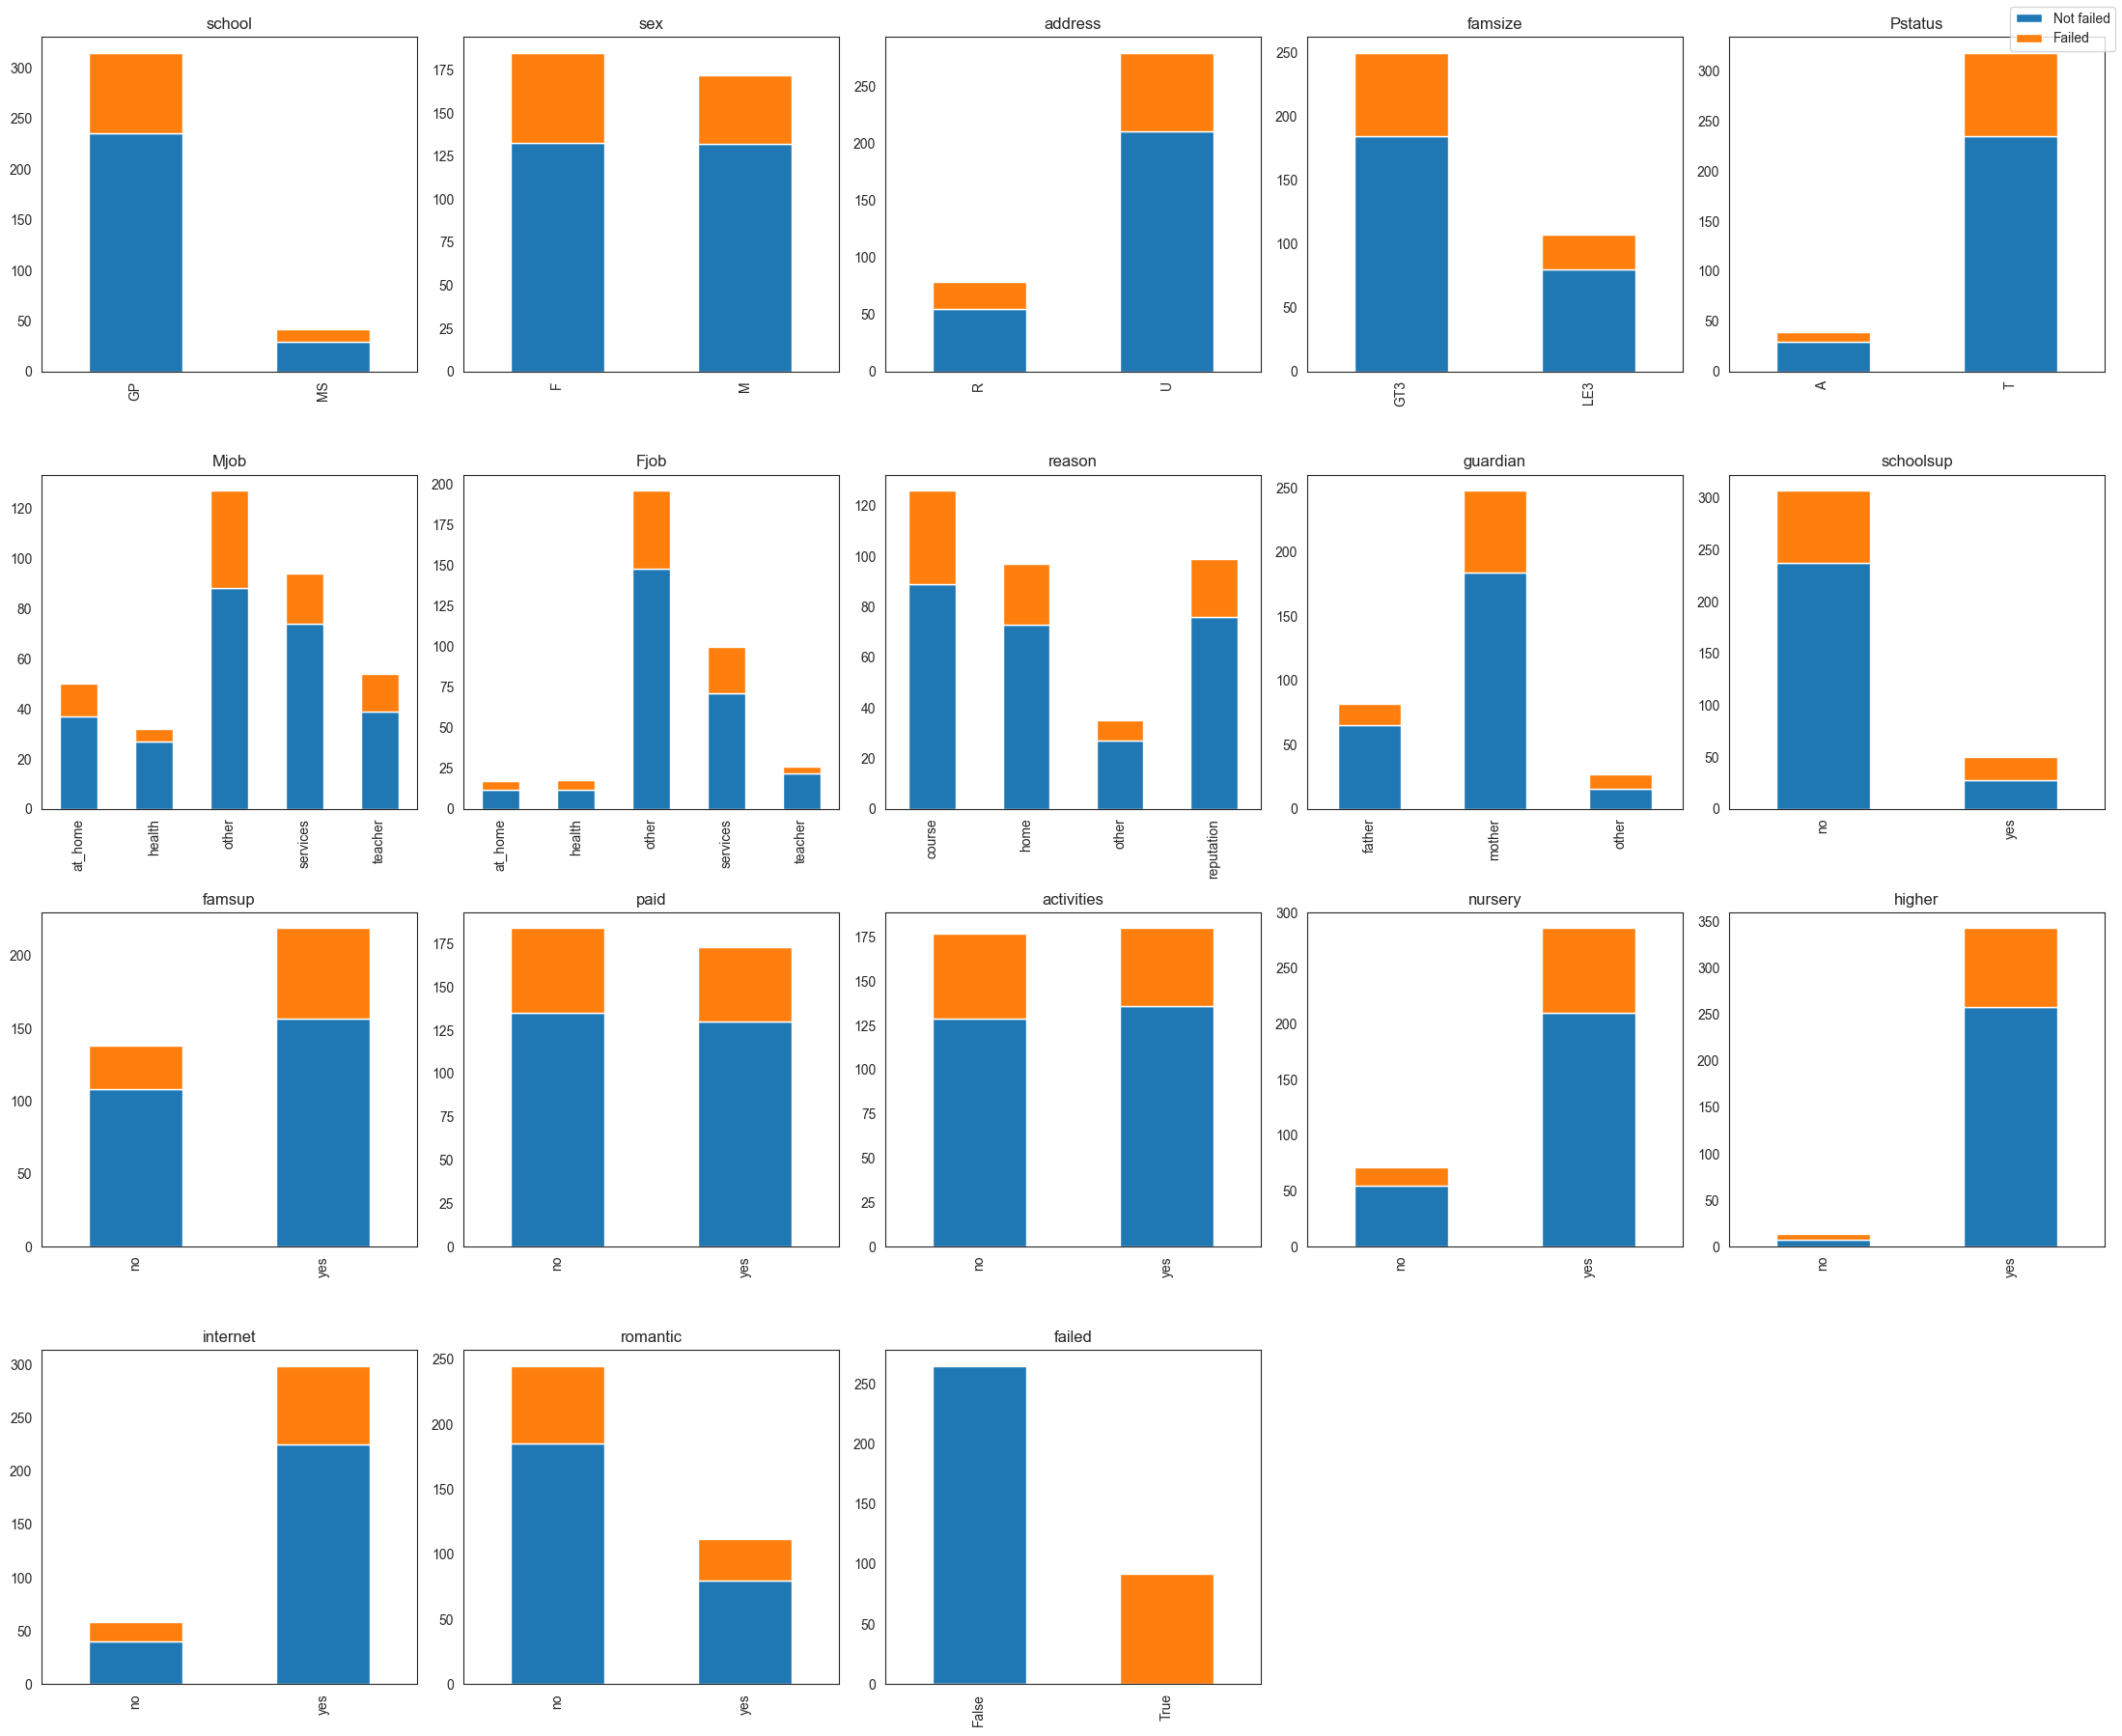

In [11]:
n_rows = 4
n_cols = 5

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 18))
axes = axes.flatten()
for i, col in enumerate(categorical):
    ax = axes[i]
    counts = df.groupby([col, 'failed']).size().unstack(fill_value=0)

    counts.plot(kind='bar', stacked=True, ax=ax, legend=False)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("")

for j in range(len(categorical), n_rows*n_cols):
    fig.delaxes(axes[j])

fig.legend(labels=["Not failed", "Failed"], loc="upper right")

plt.tight_layout()
plt.show()

##### **1.6.** In each school, how many students live in a rural area and do not have internet access at home? **(0.50)**

In [12]:
R_I = df[(df["address"] == "R") & (df["internet"] == "no")]
total_pairs = len(R_I)

count_GP = (R_I["school"] == 'GP').sum()

print(count_GP, "students from GP live in a rural area and have no internet access at home.")
print(total_pairs - count_GP, "students from MP live in a rural area and have no internet access at home.")

17 students from GP live in a rural area and have no internet access at home.
7 students from MP live in a rural area and have no internet access at home.


##### **1.7.** Split the dataset into a training set (80%) and a test set (20%). **(0.50)**

In [13]:
from sklearn.model_selection import train_test_split

test_size = 0.2
seed = 100

df_train, df_test = train_test_split(df, test_size=test_size, random_state=seed)

# Part 2 - Classification **(7.50)**

##### You'll start by approaching the problem as a classification task, predicting whether a student will pass (G3 >= 10) or fail (G3 < 10) the course. Consider the variable `failed` as the target variable.

##### **2.1.** Which performance metric do you think are most important for this prediction task, and why? Justify your answer in the context of supporting students who may struggle academically. **(2.00)**

Recall is the most important performance metric for this prediction task because it measures how many of the students who at risk of failing are correctly identified by the model. In the context of academic support, the biggest danger is missing a struggling student who needs intervention. A false negative means the model labels an at-risk student as “safe,” which could lead to that student receiving no additional help and eventually failing the course.

By prioritizing high recall, the model ensures that as many struggling students as possible are detected, allowing educators to provide targeted support and interventions. Even if this means generating more false alarms, the cost of unnecessary support is far lower than the cost of overlooking a student who needs assistance. Therefore, recall directly aligns with the goal of ensuring that no at-risk student is left unidentified.

##### **2.2.** Build a logistic regression model to predict whether a student will pass or fail the course, using as predictor the feature `absences`. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

In [14]:
def print_confusion_matrix(cm, print_metrics=False):
    tn, fp, fn, tp = cm.ravel()
    # Header
    print(f"{'':>18}{'Predicted':^8}")
    print(f"{'':>18}{'Approved':>4} {'  Failed':>4}")
    print("-" * 40)
    # Rows
    print(f"{'Actual: Approved':>14}{tn:>4} {fp:>9}")
    print(f"{'Actual:   Failed':>14}{fn:>4} {tp:>9}")
    print("-" * 40)

    if print_metrics:
        total = tn + fp + fn + tp
        accuracy = (tn + tp) / total if total else 0
        recall = tp / (tp + fn) if (tp + fn) else 0
        precision = tp / (tp + fp) if (tp + fp) else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0

        print(f"Accuracy : {accuracy:6.3f}")
        print(f"Precision: {precision:6.3f}")
        print(f"Recall   : {recall:6.3f}")
        print(f"F1-score : {f1_score:6.3f}\n")

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

X_train22 = df_train[["absences"]]
y_train22 = df_train["failed"]

X_test22 = df_test[["absences"]]
y_test22 = df_test["failed"]


model = LogisticRegression()
model.fit(X_train22, y_train22)

print('Intercept: {}'.format(model.intercept_))
print('Coefficients: {}'.format(model.coef_))
print('Classes: {}'.format(model.classes_))

y_pred22 = model.predict(X_test22)
cm = confusion_matrix(y_test22, y_pred22)

print_confusion_matrix(cm, print_metrics=True)

Intercept: [-1.29856729]
Coefficients: [[0.04225735]]
Classes: [False  True]
                  Predicted
                  Approved   Failed
----------------------------------------
Actual: Approved  56         0
Actual:   Failed  16         0
----------------------------------------
Accuracy :  0.778
Precision:  0.000
Recall   :  0.000
F1-score :  0.000



##### **2.3.** The model you built in question 2.2 likely does not perform very well. Explain why this is the case, considering the distribution of the predictor and the response. How can you improve the model? **(2.00)**

The logistic regression model performs poorly because the distribution of the predictor variable (absences) is extremely similar for both the passing and failing groups. As shown in the histogram (in question 1.4), the two distributions overlap almost completely, meaning absences do not meaningfully discriminate between students who pass and those who fail. Since logistic regression relies on differences in predictor distributions to establish a decision boundary, this lack of separation results in weak predictive performance. Additionally, the response variable is imbalanced, with far more students passing than failing, which biases the model toward the majority class and further reduces its ability to correctly identify failed students.

To improve the model, more informative predictors such as the grades G1 and G2 should be included, since they provide direct information about the student’s academic performance. However, if the objective is to detect students who are likely to fail at the beginning of the year, a model based on these grades cannot be used, because this information is not yet available at that early stage. The addition of other features may then be useful. Furthermore, the issue of class imbalance can be addressed by applying class_weight='balanced', which penalizes the model more heavily when it misclassifies failing students, encouraging better detection of this minority group. Another improvement involves adjusting the decision threshold (e.g., below 0.5), so that the model becomes more sensitive to signs of academic risk. In an educational context, this trade-off is appropriate, since incorrectly flagging a student who is actually passing is far less problematic than failing to identify a student who is in need of support.

##### **2.4.** Consider now the variable `studytime` as the predictor and assume it is numerical. Build a logistic regression model to predict whether a student will pass or fail the course. Evaluate the performance of the model on the test set using a confusion matrix, accuracy, precision, recall, f1-score and the metric you selected in question 2.1. **(0.50)**

Note: Use `sklearn.linear_model.LogisticRegression(class_weight='balanced')` for your logistic regression model.

In [16]:
X_train24 = df_train[["studytime"]]
y_train24 = df_train["failed"].astype(int)

X_test24 = df_test[["studytime"]]
y_test24 = df_test["failed"].astype(int)

model24 = LogisticRegression(class_weight='balanced')
model24.fit(X_train24, y_train24)

print('Intercept:', model24.intercept_)
print('Coefficients:', model24.coef_)
print('Classes:', model24.classes_)

y_pred24 = model24.predict(X_test24)

cm = confusion_matrix(y_test24, y_pred24)

print_confusion_matrix(cm, print_metrics=True)

Intercept: [0.2755661]
Coefficients: [[-0.13476889]]
Classes: [0 1]
                  Predicted
                  Approved   Failed
----------------------------------------
Actual: Approved  11        45
Actual:   Failed   0        16
----------------------------------------
Accuracy :  0.375
Precision:  0.262
Recall   :  1.000
F1-score :  0.416



##### **2.5.** Repeat question 2.4, but now considering `studytime` as a categorical variable. **(0.50)**

In [17]:
X_train25 = pd.get_dummies(df_train[['studytime']].astype('category'), drop_first=True)
X_test25 = pd.get_dummies(df_test[['studytime']].astype('category'), drop_first=True)

X_test25 = X_test25.reindex(columns=X_train25.columns, fill_value=0)

y_train25 = df_train['failed'].astype(int)
y_test25  = df_test['failed'].astype(int)

model25 = LogisticRegression(class_weight='balanced')
model25.fit(X_train25, y_train25)

print('Intercept:', model25.intercept_)
print('Coefficients:', model25.coef_)
print('Classes:', model25.classes_)

y_pred25 = model25.predict(X_test25)

cm = confusion_matrix(y_test25, y_pred25)

print_confusion_matrix(cm, print_metrics=True)

Intercept: [-0.09783544]
Coefficients: [[ 0.31061547 -0.3202405  -0.17401928]]
Classes: [0 1]
                  Predicted
                  Approved   Failed
----------------------------------------
Actual: Approved  25        31
Actual:   Failed   6        10
----------------------------------------
Accuracy :  0.486
Precision:  0.244
Recall   :  0.625
F1-score :  0.351



##### **2.6.** What is the difference between the two models you built in questions 2.4 and 2.5? Plot the predictions of each model over the range of `studytime` values in the test set. What are the advantages and disadvantages of each approach? **(2.00)**


In question 2.4, the logistic regression model uses studytime as a single numerical predictor, treated as a continuous or ordinal variable. This assumes that the probability of failing changes smoothly and monotonically with the number of study hours. In question 2.5, the model uses studytime as a categorical variable, encoded into dummy variables. Instead of assuming a linear relationship, each studytime level is allowed to have its own independent probability of failing.

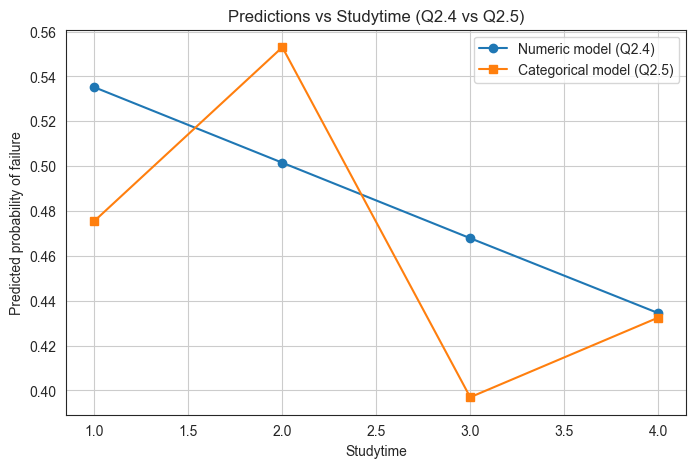

In [18]:
import numpy as np
import matplotlib.pyplot as plt

study_vals = np.sort(df_test['studytime'].unique())

study_df_num = pd.DataFrame({'studytime': study_vals})
y_prob_num = model24.predict_proba(study_df_num)[:, 1]

study_df_cat = pd.DataFrame({'studytime': study_vals})

cat_matrix = pd.get_dummies(study_df_cat[['studytime']].astype('category'), drop_first=True)

cat_matrix = cat_matrix.reindex(columns=X_train25.columns, fill_value=0)

y_prob_cat = model25.predict_proba(cat_matrix)[:, 1]

plt.figure(figsize=(8, 5))
plt.plot(study_vals, y_prob_num, marker='o', label='Numeric model (Q2.4)')
plt.plot(study_vals, y_prob_cat, marker='s', label='Categorical model (Q2.5)')
plt.xlabel('Studytime')
plt.ylabel('Predicted probability of failure')
plt.title('Predictions vs Studytime (Q2.4 vs Q2.5)')
plt.grid(True)
plt.legend()
plt.show()

Treating studytime as an ordinal numerical predictor assumes a gradual and consistent effect of additional study time on the probability of failing. This results in a simpler, more interpretable model with fewer parameters and less risk of overfitting. However, it assumes equal improvement between study levels, which may not reflect real student behavior. When studytime is used as a categorical predictor, no ordering is imposed and each level is allowed to have its own effect. This approach is more flexible and can capture non-linear or unexpected patterns. However, it increases model complexity, ignores the natural ordering of studytime, and can be more difficult to interpret.

# Part 3 - Regression (3.50)

##### In this part of the assignment, you'll approach the problem as a regression task, predicting the actual final grade `G3`. Use the same training and test sets you created in Part 1.

##### **3.1.** Build a linear regression model to predict the final grade `G3`, using as predictor the feature `G2`. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). **(0.50)**


In [19]:
def evaluate_regression_model(model, X_test, y_test, y_pred):
   
    print('Intercept:', model.intercept_)
    print('Coefficients:', model.coef_)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print('--- Model Evaluation ---')
    print('MSE:', mse)
    print('R^2:', r2)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_train31 = df_train[['G2']]
y_train31 = df_train['G3']

X_test31 = df_test[['G2']]
y_test31 = df_test['G3']

model31 = LinearRegression()
model31.fit(X_train31, y_train31)

y_pred31 = model31.predict(X_test31)

evaluate_regression_model(model31, X_test31, y_test31, y_pred31)

Intercept: 0.04478017030365322
Coefficients: [1.00686135]
--- Model Evaluation ---
MSE: 0.7494285775643255
R^2: 0.9234203708489028


##### **3.2.** Print the equation of the model you built in question 3.1. Plot the predictions of the model as a function of the inputs, along with the actual data points from the test set. Interpret the coefficients of the model. **(1.00)**


In [21]:
import numpy as np
import matplotlib.pyplot as plt

intercept31 = model31.intercept_
coef31 = model31.coef_[0]

print("Model Equation:")
print("G3 =", intercept31, "+", coef31, "× G2")

print("Interpretation:")
print("- Intercept (", intercept31, "): Baseline expected G3 when G2 = 0.")
print("- Coefficient (", coef31, "): For a 1-point increase in G2, predicted G3 increases by this amount.")

Model Equation:
G3 = 0.04478017030365322 + 1.0068613549717553 × G2
Interpretation:
- Intercept ( 0.04478017030365322 ): Baseline expected G3 when G2 = 0.
- Coefficient ( 1.0068613549717553 ): For a 1-point increase in G2, predicted G3 increases by this amount.


The ratio between G2 and G3 is almost one-to-one, and students are more likely to slightly increase their grades than decrease them (both the intercept and coefficient are positive). However, considering that the goal is to support students who struggle academically, this linear regression offers little value: if a student is already performing poorly by the second period, the model indicates they are unlikely to improve enough to pass. Therefore, meaningful intervention must occur before G2 rather than relying on predictions at this stage.

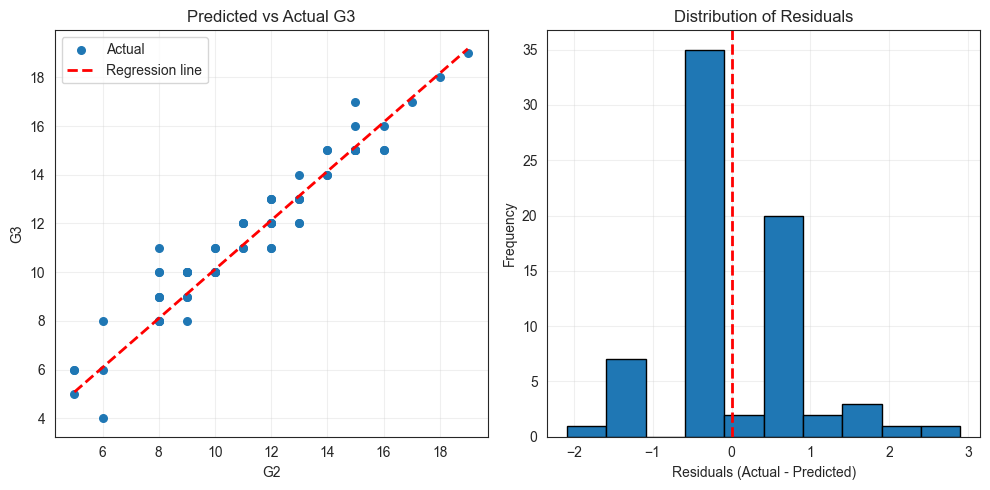

Residuals Summary:
Mean: 0.21098173321011285
Median: -0.1133937200212074
Std Dev: 0.845484281417017
Min: -2.085948300134185
Max: 2.900328989922304


In [22]:
residuals31 = y_test31 - y_pred31

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(X_test31, y_test31, label='Actual', s=30)

x_line31 = np.linspace(X_test31.min(), X_test31.max(), 100)
x_line31 = pd.DataFrame(x_line31, columns=['G2'])
y_line31 = model31.predict(x_line31)

axes[0].plot(x_line31, y_line31, 'r--', linewidth=2, label='Regression line')
axes[0].set_xlabel('G2')
axes[0].set_ylabel('G3')
axes[0].set_title('Predicted vs Actual G3')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(residuals31, bins=10, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Residuals Summary:")
print("Mean:", residuals31.mean())
print("Median:", np.median(residuals31))
print("Std Dev:", residuals31.std())
print("Min:", residuals31.min())
print("Max:", residuals31.max())


##### **3.3.** Build a linear regression model to predict the final grade `G3`, using as predictors all features except the variables related to the grades (`G1`, `G2`, `G3`, `failed`). Explain the choices you made. Evaluate the performance of the model on the test set using Mean Squared Error (MSE) and R-squared ($R^2$). Plot the predicted vs actual values of `G3` for the test set. **(1.00)**

Two models: one keeping the ordinal variables as numeric (Model A); the other one-hot encoding the ordinal variables (Model B)

Model A

In [25]:
categorical = [col for col in categorical if col != 'failed']
features_no_grades = list(set(numerical + categorical + ordinal) - set(['G1', 'G2', 'G3', 'failed']))

X_train33A = df_train[features_no_grades].copy()
X_test33A  = df_test[features_no_grades].copy()

X_train33A = pd.get_dummies(X_train33A, columns=categorical, drop_first=True)
X_test33A  = pd.get_dummies(X_test33A,  columns=categorical, drop_first=True)

X_test33A = X_test33A.reindex(columns=X_train33A.columns, fill_value=0)

y_train33 = df_train['G3']
y_test33  = df_test['G3']

model33A = LinearRegression()
model33A.fit(X_train33A, y_train33)

y_pred33A = model33A.predict(X_test33A)

print("Model A: Ordinal variables kept as numeric")
evaluate_regression_model(model33A, X_test33A, y_test33, y_pred33A)

Model A: Ordinal variables kept as numeric
Intercept: 14.718746056427719
Coefficients: [ 1.47772815e-01  2.73293256e-02 -5.89536768e-02  8.68597925e-02
  4.12045656e-01  3.14221657e-01 -1.83038997e-01 -2.45118282e-01
 -1.34383205e-01 -8.76511918e-01 -3.66914156e-01  2.16006802e-01
 -4.44354284e-02 -5.26052568e-01  6.20478410e-01  9.53084951e-01
 -1.99870982e-01  3.08267922e-02  3.68490764e-01 -1.18827867e+00
  2.28068891e-01 -1.23685530e+00 -5.69477517e-01 -8.43663804e-01
 -9.87070006e-01  1.10068821e+00  2.97656982e-01 -2.29612992e-01
 -1.37623325e-03 -8.32688294e-02  6.03713406e-01 -2.45566603e+00
 -8.25385573e-01 -4.09046662e-01  3.17277947e-01 -1.48093022e-01
  3.46352030e-01  7.87091989e-01 -3.95563256e-02]
--- Model Evaluation ---
MSE: 7.755117703703322
R^2: 0.20755085200666212


In [ ]:
Model B

In [27]:
X_train33B = df_train[features_no_grades].copy()
X_test33B  = df_test[features_no_grades].copy()

X_train33B = pd.get_dummies(X_train33B, columns=categorical + ordinal, drop_first=True)
X_test33B  = pd.get_dummies(X_test33B,  columns=categorical + ordinal, drop_first=True)

X_test33B = X_test33B.reindex(columns=X_train33B.columns, fill_value=0)

model33B = LinearRegression()
model33B.fit(X_train33B, y_train33)

y_pred33B = model33B.predict(X_test33B)

print("Model B: One-hot encode ordinal variables")
evaluate_regression_model(model33B, X_test33B, y_test33, y_pred33B)

Model B: One-hot encode ordinal variables
Intercept: 14.55435054399734
Coefficients: [-0.16563182 -0.03765946 -0.20326104  0.75122647  1.31924351 -0.40565052
  0.16818226  0.37217948 -1.12572664  0.05913499 -1.31526599 -0.33298873
 -0.29384966 -0.41916089  1.48471371  0.2320502  -0.04971986  0.13995068
 -0.22177391  0.7229654  -2.08394604 -0.90944658 -0.26123681  0.09350628
 -0.09251421  0.64655899  0.97010385  0.03215081 -0.1626677  -0.17417852
  0.10727444  0.57256393 -0.67248561  0.29127293 -0.50207408 -0.53520371
 -0.23194929  0.42398    -0.2526835   0.11063843  1.39845063  0.59737305
 -0.64899791 -2.6101885  -2.6821924   0.99334755  0.09163201  0.22078357
  0.77249388  1.01417778  0.3653437   0.46251961  1.27583137 -0.11792966
 -0.81895859 -1.16468295 -1.5794671   0.42860408 -0.03903965 -0.29159682
 -1.69606069 -0.5570245  -0.35943446 -1.33761139  1.46106797 -0.14549152
 -1.6967125  -0.91818407 -1.12735753]
--- Model Evaluation ---
MSE: 9.873002104114109
R^2: -0.008863102336346795

Two models: Model A (with F-test to determine the most useful variables); Model A (with L1 to determine the most useful variables)

Model A: Using F-test for feature selection

In [62]:
from sklearn.feature_selection import SelectKBest, f_regression

selector33 = SelectKBest(score_func=f_regression, k=20)
selector33.fit(X_train33A, y_train33)

selected_cols33 = X_train33A.columns[selector33.get_support()]

print("Selected Features Using F-Test:")
print(list(selected_cols33))

X_train33_fs = selector33.transform(X_train33A)
X_test33_fs  = selector33.transform(X_test33A)

model33_fs = LinearRegression()
model33_fs.fit(X_train33_fs, y_train33)

y_pred33_fs = model33_fs.predict(X_test33_fs)

print("Model A: Using F-test for feature selection:")
evaluate_regression_model(model33_fs, X_test33_fs, y_test33, y_pred33_fs)

Selected Features Using F-Test:
['Dalc', 'traveltime', 'Fedu', 'studytime', 'Medu', 'age', 'health', 'Walc', 'failures', 'goout', 'absences', 'school_MS', 'sex_M', 'address_U', 'Mjob_health', 'Mjob_other', 'Mjob_services', 'Fjob_teacher', 'schoolsup_yes', 'internet_yes']
Model A: Using F-test for feature selection:
Intercept: 13.42514016515745
Coefficients: [ 0.08251928 -0.0084207  -0.05372006  0.3898879   0.10812296 -0.09410845
 -0.2729109  -0.18417288 -0.81010849 -0.31918508 -0.04409269 -0.50890335
  0.88755055  0.90736304  1.13136107 -0.35226222  0.93603995  1.72778612
 -2.30469872  0.47575178]
--- Model Evaluation ---
MSE: 6.995044289234426
R^2: 0.28521821344730613


In [64]:
from sklearn.linear_model import Lasso

# L1 regularization (Lasso)
lasso33 = Lasso(alpha=0.02)  # you can tune alpha later
lasso33.fit(X_train33B, y_train33)

# Identify selected (non-zero) features
coef_mask33 = lasso33.coef_ != 0
selected_cols_l1 = X_train33B.columns[coef_mask33]

print("Selected Features Using L1:")
print(list(selected_cols_l1))

# Keep only selected features
X_train33_l1 = X_train33B[selected_cols_l1]
X_test33_l1  = X_test33B[selected_cols_l1]

# Fit linear regression on selected features
model33_l1 = LinearRegression()
model33_l1.fit(X_train33_l1, y_train33)

# Predict
y_pred33_l1 = model33_l1.predict(X_test33_l1)

print("Model B: Using L1 for feature selection:")
evaluate_regression_model(model33_l1, X_test33_l1, y_test33, y_pred33_l1)

Selected Features Using L1:
['age', 'absences', 'school_MS', 'sex_M', 'address_U', 'famsize_LE3', 'Mjob_health', 'Mjob_other', 'Mjob_teacher', 'Fjob_services', 'Fjob_teacher', 'reason_home', 'reason_reputation', 'guardian_mother', 'guardian_other', 'schoolsup_yes', 'famsup_yes', 'paid_yes', 'activities_yes', 'internet_yes', 'Medu_1', 'Medu_3', 'Medu_4', 'Fedu_1', 'Fedu_2', 'traveltime_2', 'studytime_2', 'studytime_3', 'studytime_4', 'failures_1', 'failures_2', 'failures_3', 'famrel_2', 'famrel_5', 'freetime_2', 'freetime_3', 'freetime_5', 'goout_2', 'goout_3', 'goout_4', 'goout_5', 'Walc_2', 'Walc_3', 'Walc_4', 'health_3', 'health_4', 'health_5']
Model B: Using L1 for feature selection:
Intercept: 15.10080799989858
Coefficients: [-0.17326866 -0.0394769  -0.22259829  0.81720949  1.16980968 -0.2912349
  0.27834054 -1.21874326 -1.22278581 -0.22341148  1.72764864  0.29878845
  0.19294132 -0.25948171  0.62827278 -2.18049115 -0.8627386  -0.26184014
  0.16830337  0.90425025  0.01395813  0.301

Hybrid Model: the ordinal variables were split into numerical and categorical based on the mean and distribution of each category as a function of the G3 (seen below) (the same 'selection' techniques used above)

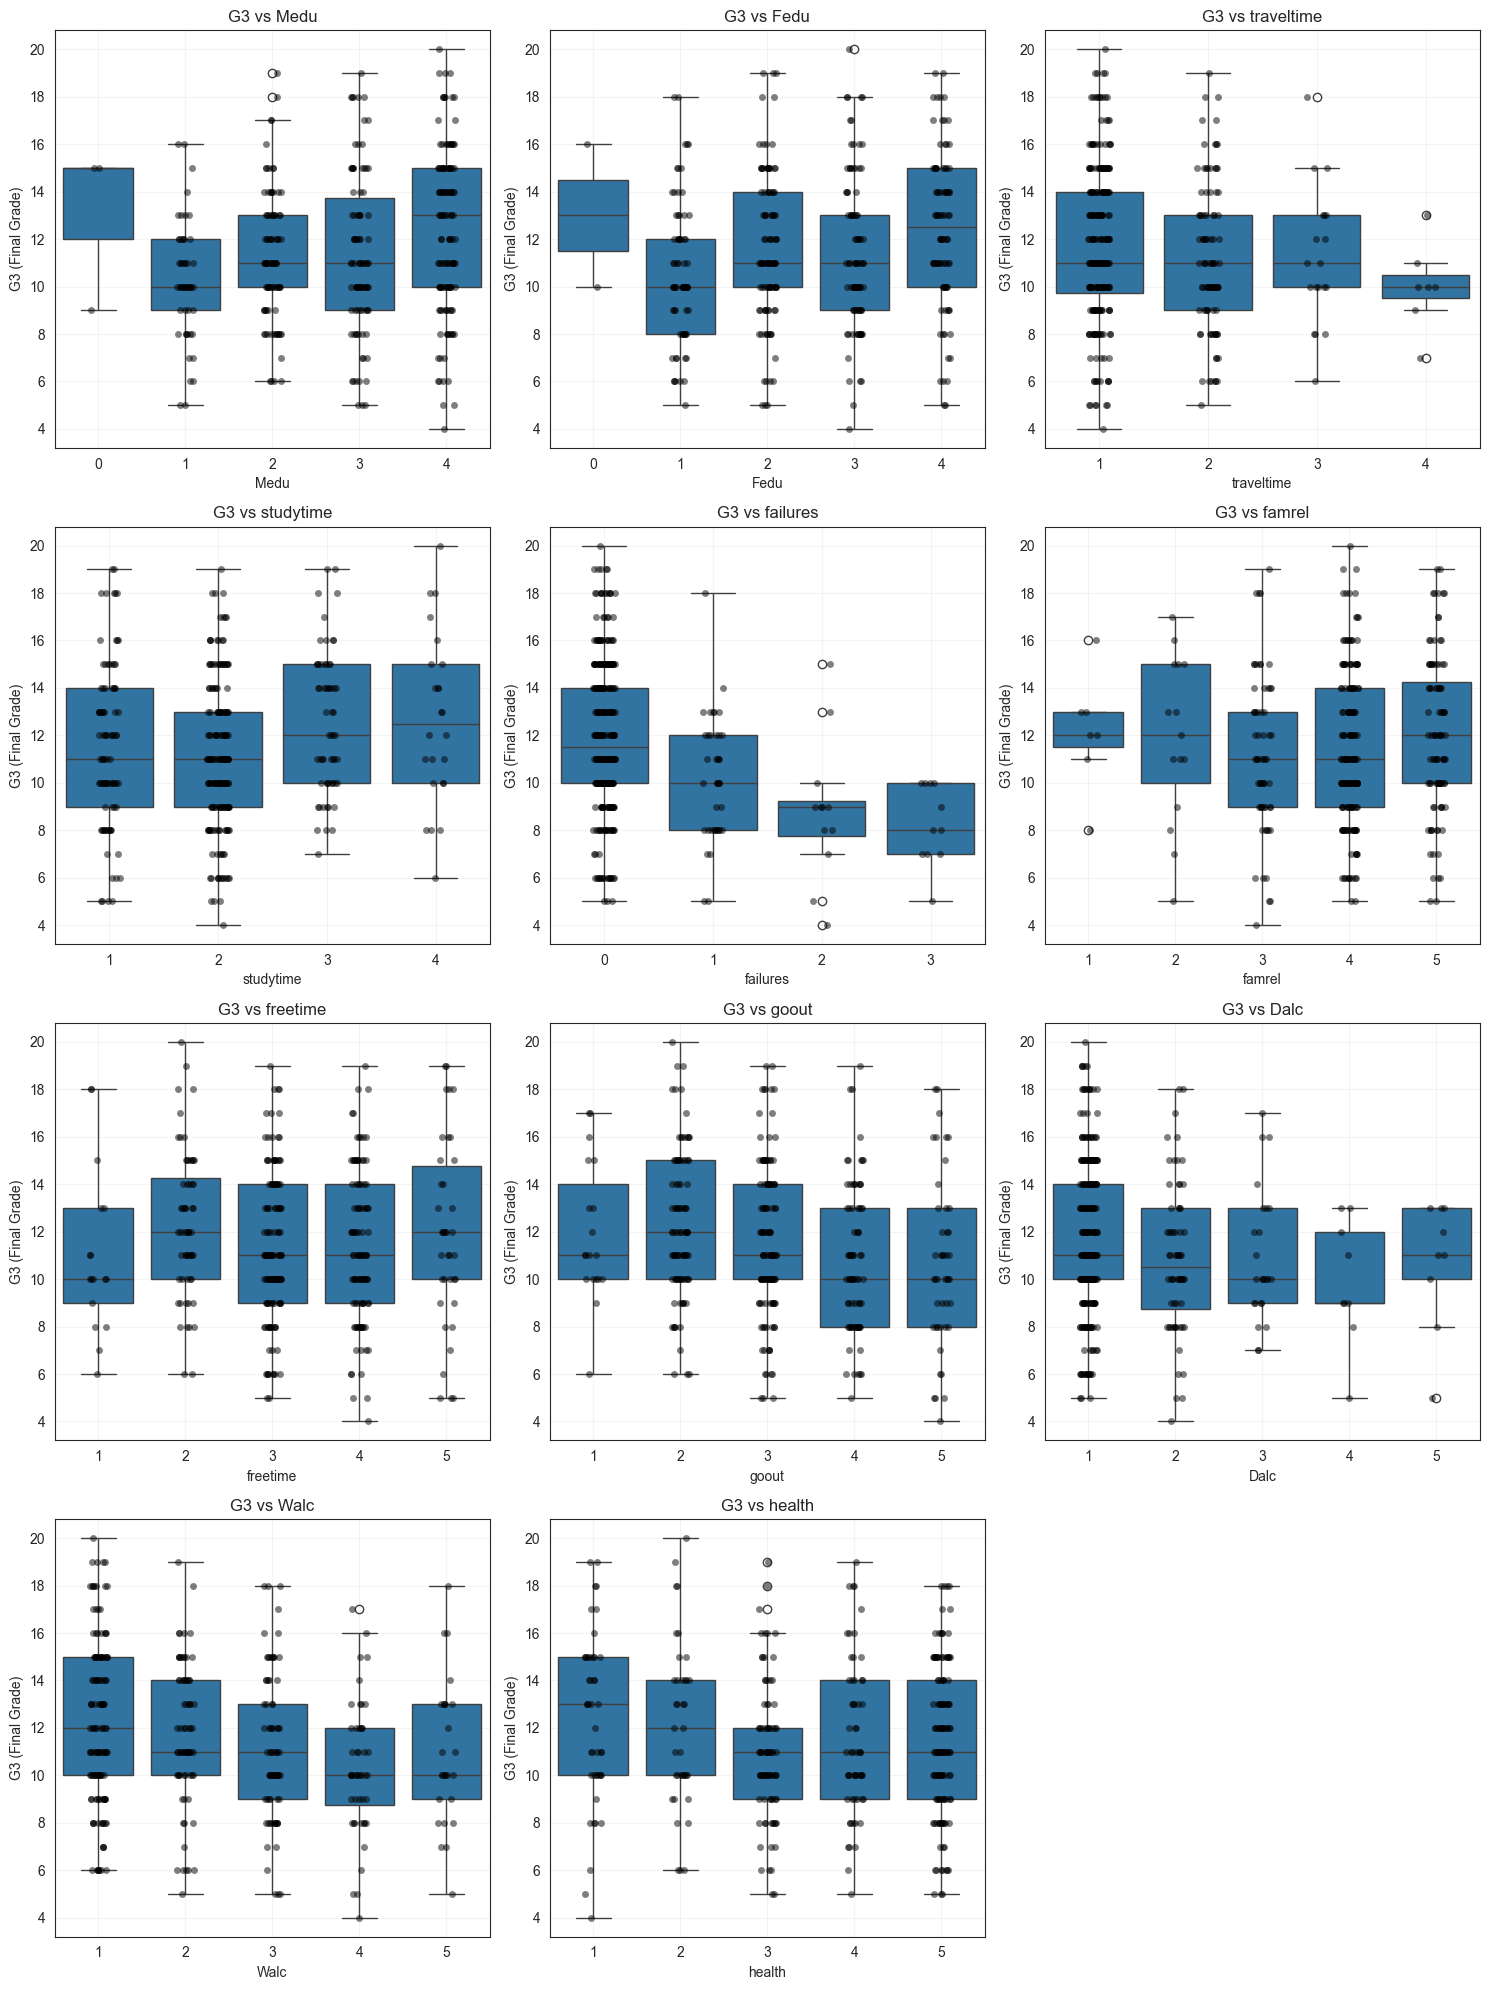

In [70]:
import math

data = df  
n_cols = 3
n_rows = math.ceil(len(ordinal) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(ordinal):
    ax = axes[i]
    sns.boxplot(x=data[col], y=data["G3"], ax=ax)
    sns.stripplot(x=data[col], y=data["G3"], color='black', alpha=0.5, jitter=True, ax=ax)
    ax.set_title(f"G3 vs {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("G3 (Final Grade)")
    ax.grid(True, alpha=0.2)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [79]:
df_train = df_train.drop(columns=['failures', 'health'], errors='ignore')
df_test  = df_test.drop(columns=['failures', 'health'], errors='ignore')

numeric_feats = ['age','absences','studytime','traveltime','freetime','goout','Dalc','Walc','famrel']
categorical_feats = [col for col in df_train.columns 
                     if col not in numeric_feats + ['G1','G2','G3','failed']]

selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(df_train[numeric_feats], df_train['G3'])

numeric_selected = pd.Series(selector.scores_, index=numeric_feats)
numeric_keep = numeric_selected[numeric_selected > np.median(numeric_selected)].index.tolist()


X_cat_train = pd.get_dummies(df_train[categorical_feats], drop_first=True)
X_cat_test  = pd.get_dummies(df_test[categorical_feats],  drop_first=True)

X_cat_train, X_cat_test = X_cat_train.align(X_cat_test, join='left', axis=1, fill_value=0)

lasso = Lasso(alpha=0.1, max_iter=5000)
lasso.fit(X_cat_train, df_train['G3'])

cat_selected = X_cat_train.columns[lasso.coef_ != 0].tolist()

final_features = numeric_keep + cat_selected
print("Total selected:", len(final_features))

X_train_A = pd.concat([df_train[numeric_keep], X_cat_train[cat_selected]], axis=1)
X_test_A  = pd.concat([df_test[numeric_keep],  X_cat_test[cat_selected]], axis=1)

model_H = LinearRegression()
model_H.fit(X_train_A, df_train['G3'])
y_pred_H = model_H.predict(X_test_A)

print("Model Hybrid: Using F-test and L1 for feature selection:")
evaluate_regression_model(model_H, X_test_A, df_test['G3'], y_pred_H)

Total selected: 15
Model Hybrid: Using F-test and L1 for feature selection:
Intercept: 14.861275791766124
Coefficients: [-0.21036186 -0.05067875 -0.321923   -0.25857433  0.26857326  0.03568615
  0.4349543   1.16783396 -0.63494896  0.39391129  1.60648584 -2.41549554
 -0.78797752  0.4495691   0.88513495]
--- Model Evaluation ---
MSE: 8.369932614233985
R^2: 0.14472658928902904


The predicted vs actual values of G3 for the best model are plotted below. 

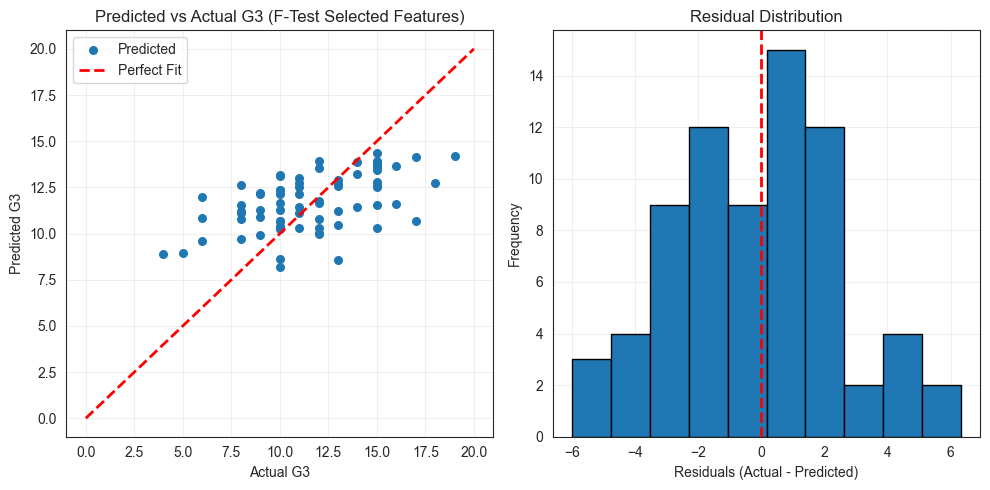

Residuals Summary:
Mean: -0.1120
Median: 0.1223
Std Dev: 2.6610
Min: -5.9799
Max: 6.3165


In [78]:
residuals33 = y_test33 - y_pred33_fs

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].scatter(y_test33, y_pred33_fs, s=30, label='Predicted')
axes[0].plot([0,20], [0,20], 'r--', linewidth=2, label='Perfect Fit')
axes[0].set_xlabel('Actual G3')
axes[0].set_ylabel('Predicted G3')
axes[0].set_title('Predicted vs Actual G3 (F-Test Selected Features)')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].hist(residuals33, bins=10, edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Residuals Summary:")
print(f"Mean: {residuals33.mean():.4f}")
print(f"Median: {np.median(residuals33):.4f}")
print(f"Std Dev: {residuals33.std():.4f}")
print(f"Min: {residuals33.min():.4f}")
print(f"Max: {residuals33.max():.4f}")

The F-test highlights numerical variables with stronger linear relationships to the target, while L1 (Lasso) eliminates unhelpful one-hot encoded categorical features by shrinking their coefficients to zero. Although not always optimal for every approach, applying these selectors to Models A and B reduced noise and highlighted the most informative variables, which led to an improvement in predictive performance compared with using all features without selection.

Treating ordinal variables as numeric proved more effective, since their ordered scale provides useful information that the model can directly interpret. This approach improves prediction compared to one-hot encoding, which breaks the order into separate categories. However, it does not account for the fact that the distances between ordinal levels may not be equal, meaning the model assumes uniform differences that might not fully reflect reality.


##### **3.4.** In terms of application, what is the difference between building a model to predict student performance using the grades of the previous periods (as in question 3.1) versus using other features (as in question 3.3)? When would each approach be more appropriate? **(1.00)**

Using grades from previous periods to predict student performance relies directly on a student’s demonstrated academic history. This typically yields more accurate forecasts, since past achievement strongly reflects future outcomes. In contrast, models based on other factors focus on characteristics that influence learning, such as behavior, attendance, or family context, rather than the results themselves. Although this approach is generally less precise, it provides insight into the underlying conditions affecting performance and is valuable when prior grades are unavailable or when the aim is to understand and address potential learning difficulties.

Predicting student performance using previous grades relies directly on academic history, meaning the model captures learning progress and produces highly accurate predictions once past evaluations exist. In contrast, predicting performance using other features focuses on external or behavioral factors that influence learning rather than academic results themselves. This makes the second approach less precise but more useful for identifying underlying causes of poor performance and for anticipating difficulties even before grades are available.

# Part 4 - Cross-validation (4.00)

##### **4.1.** Explain the concept of cross-validation and its importance in evaluating machine learning models. **(1.00)**

Cross-validation is a resampling method used to estimate how well a machine learning model will perform on unseen data. Instead of relying on a single train–test split, it repeatedly trains the model on different portions of the training set and evaluates it on the remaining parts. The average performance across all folds provides a more stable and reliable estimate of the model’s error.

This approach reduces bias and variability compared to a single split and avoids data leakage, since the test set is not used to select models or tune hyperparameters. As highlighted in the lecture, repeatedly evaluating choices on the test set leads to overly optimistic estimates, whereas cross-validation keeps all decisions within the training data. Using 5 or 10 folds offers a good balance between accuracy and computational cost, ensuring that the selected model generalizes well.

##### **4.2.** Describe how K-fold cross-validation works. What values of K should be used? Justify. **(1.00)**

K-fold cross-validation divides the dataset into K equally sized folds. The model is trained K separate times, each time using K minus 1 folds for training and the remaining fold for validation. The error values from the K validation folds are then averaged, so the final estimate reflects how the model performs across different subsets of the data instead of relying on a single split.

The choice of K is tied to the bias–variance trade-off. Very large values of K lead to low bias but high variance and high computational cost, while very small values produce high bias and less reliable estimates of performance. Using K equal to 5 or 10 is common because it provides a balanced compromise between bias and variance without excessive computation.


##### **4.3.** Explain how K-Fold cross-validation should be done to choose the classification threshold for the logistic regression model of Part 2. **(2.00)**

To choose the classification threshold for the logistic regression model in Part 2, the threshold should be treated as a tunable hyperparameter and selected using K-fold cross-validation on the training set only. A grid of possible threshold values is defined, and for each value the model predicts class probabilities on the validation folds and computes a chosen performance metric such as precision, recall or F1-score.

By estimating the metric across all folds for every threshold in the grid, cross-validation provides a reliable comparison between alternatives. The threshold that yields the best average metric is then selected and used when retraining the model on the entire training set. Only after this tuning process is complete should the model be evaluated once on the test set. This ensures that the threshold selection does not leak information from the test data and that the final performance estimate remains valid.

# Part 5 - GitHub (1.00)

##### **5.1.** Describe how your group used GitHub to track changes throughout the project and explain why maintaining a clear change history is important in data analysis and machine learning work. **(1.00)**

The assignment tasks were completed using separate GitHub branches, with each question developed independently. A branch was only merged into the main branch once the group had finished the exercise and agreed on the final answer. Although this workflow helped keep the project organized, a few merge conflicts were not fully resolved, which caused issues in the main branch and required additional adjustments before we could continue working on the project.

Maintaining a clear and accurate change history is especially important in data analysis and machine-learning work because even small modifications to preprocessing steps, feature selection, or model parameters can significantly affect the final results. A well-tracked version history allows the team to reproduce earlier outcomes, understand how the analysis evolved, and quickly identify which changes improved or harmed the model’s performance. It also supports better collaboration, ensures transparency, and prevents accidental loss of important work—critical factors when building reliable automated systems like our student-performance prediction model.